In [137]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

In [138]:
X, y_true = make_blobs(n_samples=500, centers=3, cluster_std=0.60, random_state=42)

In [139]:
df = pd.DataFrame(X, columns=["Feature_1","Feature_2"])
df.head()

,Feature_1,Feature_2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324


In [140]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [141]:
inertia = []
k_range = range(1,11)

for i in k_range:
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

inertia
# here we can cleary see that k=3 is the best value as at 3 the elbow bend starts

[1000.0000000000002,
 297.8954141051722,
 11.575484723104978,
 9.752067977356838,
 8.25717527244628,
 6.9175773204167985,
 6.334755391595288,
 5.70417717790143,
 5.0602341335320755,
 4.762361898130396]

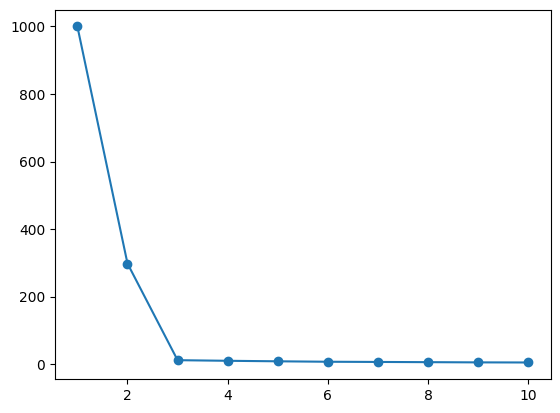

In [142]:
plt.plot(k_range,inertia,marker="o")

In [143]:
kmeans_final = KMeans(n_clusters=3,random_state=42)

# now we want the clusted labels and turn it into a column
cluster_labels = kmeans_final.fit_predict(X_scaled)
df["clusters"] = cluster_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

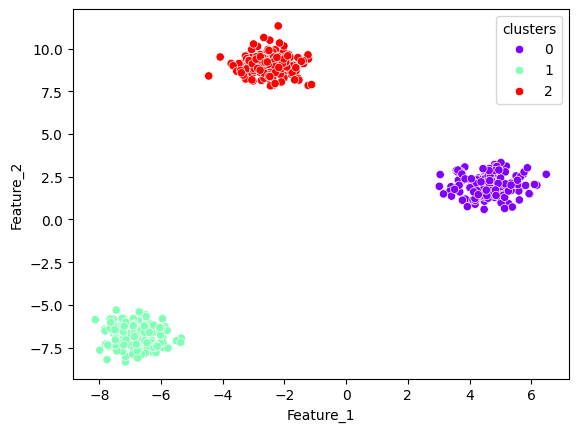

In [144]:
# now we will create a scatter plot to visually see the different clusters
sns.scatterplot(x=df["Feature_1"], y=df["Feature_2"], hue=df["clusters"], palette="rainbow")